# TEMP — All-trial sensor minimum and saturation check

**Purpose:** Read every processed trial from the six metals plus graphite at every temperature, report the minimum Primary and Secondary sensor values, and look for evidence that different metals collapse onto a common sensor floor.

This notebook is intentionally standalone and safe to delete. It does not train an ESN or regressor and does not modify the processed data.

The notebook distinguishes:

- **absolute minimum:** the lowest recorded processed sensor value;
- **baseline-centered minimum:** minimum after subtracting the first sample in that trial;
- **near-minimum fraction:** fraction of samples close to the trial minimum;
- **longest near-minimum run:** consecutive samples close to the minimum.

A shared absolute minimum accompanied by long near-minimum plateaus is stronger evidence of saturation than visually similar curve shapes alone.

The focused materials are aluminum, bismuth, copper, iron, nickel, titanium and graphite. Other materials are intentionally excluded from all downstream tables and figures.


For cross-condition response-height comparisons, every trial is aligned to its detected Primary-response elbow. The elbow becomes both the common time origin and the signal reference for Primary and Secondary. Absolute sensor minima are still retained in separate tables because centering removes information about a possible shared electronic floor.


# 1. Imports and configuration

In [42]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from matplotlib.lines import Line2D

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
SENSOR_COLUMNS = ("Primary", "Secondary")

# Saturation-focused subset: six metals plus graphite.
FOCUS_MATERIALS = (
    "aluminum", "bismuth", "copper", "iron",
    "nickel", "titanium", "graphite",
)

# A sample is considered near its trial minimum when it lies within this
# fraction of the trial's robust 5th-to-95th percentile range.
NEAR_MIN_RANGE_FRACTION = 0.02
MINIMUM_ABSOLUTE_TOLERANCE = 1e-12

# Common time and signal reference is the detected Primary-response elbow.
CONTACT_SMOOTH_WINDOW = 15
CONTACT_POLYORDER = 2
CONTACT_THRESHOLD_FRACTION = 0.30
CONTACT_SKIP_SAMPLES = 5

# Keep the entire available post-elbow signal. Set a number such as 15.0 to
# restrict every trial to the same maximum number of seconds after contact.
MAX_SECONDS_AFTER_ELBOW = None

# Number of common time samples used in the consolidated mean ± SD figure.
OVERLAY_TIME_POINTS = 201

# Set to an integer to show only that many lowest-minimum trials; None shows all.
LOWEST_TRIALS_TO_DISPLAY = 30

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
OUTPUT_DIR = PROJECT_ROOT / "results" / "temporary_saturation_check"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data root:", DATA_ROOT)
print("Output directory:", OUTPUT_DIR)


Data root: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/data/02_preprocessed
Output directory: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check


# 2. Load every processed trial

In [43]:
required = {"Sample", "Trial", "Time", *SENSOR_COLUMNS}
frames = []
load_log = []

for temperature in TEMPERATURE_FOLDERS:
    folder = DATA_ROOT / temperature
    if not folder.is_dir():
        raise FileNotFoundError(folder)
    for path in sorted(folder.glob("*.csv")):
        frame = pd.read_csv(path)
        missing = required - set(frame.columns)
        if missing:
            warnings.warn(f"Skipping {temperature}/{path.name}; missing {sorted(missing)}")
            continue
        frame = frame.copy()
        frame["Temperature"] = temperature
        frame["source_file"] = path.name
        frames.append(frame)
        load_log.append({"Temperature": temperature, "file": path.name, "rows": len(frame)})

if not frames:
    raise ValueError("No valid processed CSV files were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", *SENSOR_COLUMNS):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=["Sample", "Trial", "Time", *SENSOR_COLUMNS]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
DATA["Sample"] = (
    DATA["Sample"].astype(str).str.strip().str.lower().str.replace(" ", "_")
)

available_materials = sorted(DATA["Sample"].unique())
missing_focus = sorted(set(FOCUS_MATERIALS) - set(available_materials))
if missing_focus:
    raise KeyError(
        f"FOCUS_MATERIALS not found in processed data: {missing_focus}. "
        f"Available materials: {available_materials}"
    )
DATA = DATA[DATA["Sample"].isin(FOCUS_MATERIALS)].copy()

DATA["trial_id"] = (
    DATA["Temperature"].astype(str) + "__" + DATA["Sample"]
    + "_trial_" + DATA["Trial"].astype(str)
)
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)

print(f"Rows loaded: {len(DATA):,}")
print("Focused materials:", DATA["Sample"].nunique(), list(FOCUS_MATERIALS))
print("Temperature-specific trials:", DATA["trial_id"].nunique())
display(pd.DataFrame(load_log).groupby("Temperature").agg(files=("file", "size"), rows=("rows", "sum")))


Rows loaded: 11,727
Focused materials: 7 ['aluminum', 'bismuth', 'copper', 'iron', 'nickel', 'titanium', 'graphite']
Temperature-specific trials: 54


,files,rows
Temperature,,
30C,84,16650
40C,84,19263
50C,84,17239
60C,84,17328


# 3. Detect the response elbow and create a shared origin

The Primary response is smoothed only for elbow detection. The algorithm finds the strongest negative rate of change and walks backward to the beginning of that transition.

For every focused material, temperature and repetition:

\[
t_{\mathrm{aligned}}=t-t_{\mathrm{elbow}}
\]

and, for each sensor,

\[
\Delta s(t)=s(t)-s(t_{\mathrm{elbow}}).
\]

The raw sensor value at the elbow is obtained by interpolation. Thus every trial has the same physical interpretation: **time zero is detected contact and signal zero is the sensor level at detected contact**. Only post-elbow samples are retained for the downstream minimum and plateau analyses.

In [44]:
def find_contact_elbow(trial):
    clean = (
        trial[["Time", "Primary"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates("Time")
        .reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    skip = int(CONTACT_SKIP_SAMPLES)
    if len(signal) < skip + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid samples for elbow detection.")

    work_time = time[skip:]
    work_signal = signal[skip:]
    window = min(int(CONTACT_SMOOTH_WINDOW), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum_window = int(CONTACT_POLYORDER) + 2
    if minimum_window % 2 == 0:
        minimum_window += 1
    if window < minimum_window:
        raise ValueError("Sequence is too short for elbow smoothing.")

    smoothed = savgol_filter(
        work_signal, window, CONTACT_POLYORDER, mode="interp"
    )
    derivative = np.gradient(smoothed, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < CONTACT_THRESHOLD_FRACTION * derivative[strongest]
    elbow_index = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow_index = position + 1
            break
    return float(work_time[elbow_index])


aligned_parts = []
alignment_rows = []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        elbow_time = find_contact_elbow(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue

    original_time = trial["Time"].to_numpy(float)
    trial["time_from_elbow"] = trial["Time"] - elbow_time
    for sensor in SENSOR_COLUMNS:
        baseline = float(np.interp(
            elbow_time, original_time, trial[sensor].to_numpy(float)
        ))
        trial[f"{sensor}_elbow_baseline"] = baseline
        trial[f"{sensor}_aligned"] = trial[sensor] - baseline

    keep = trial["time_from_elbow"] >= 0
    if MAX_SECONDS_AFTER_ELBOW is not None:
        keep &= trial["time_from_elbow"] <= float(MAX_SECONDS_AFTER_ELBOW)
    trial = trial[keep].copy()
    if len(trial) < 5:
        warnings.warn(f"Skipping {trial_id}: fewer than five post-elbow samples")
        continue

    aligned_parts.append(trial)
    alignment_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "elbow_time": elbow_time,
        "post_elbow_samples": len(trial),
        "post_elbow_duration": float(trial["time_from_elbow"].max()),
    })

if not aligned_parts:
    raise ValueError("No trials remained after elbow alignment.")

DATA = pd.concat(aligned_parts, ignore_index=True)
ALIGNMENT = pd.DataFrame(alignment_rows)
ALIGNMENT.to_csv(OUTPUT_DIR / "trial_elbow_alignment.csv", index=False)

print("Elbow-aligned trials:", DATA["trial_id"].nunique())
print("Common origin: time_from_elbow = 0 and aligned sensor response = 0")
display(ALIGNMENT.head())


Elbow-aligned trials: 54
Common origin: time_from_elbow = 0 and aligned sensor response = 0


,trial_id,Temperature,Sample,Trial,elbow_time,post_elbow_samples,post_elbow_duration
0,30C__graphite_trial_1,30C,graphite,1,8.60070,111,11.00000
1,30C__graphite_trial_2,30C,graphite,2,7.50066,115,11.40004
2,30C__graphite_trial_3,30C,graphite,3,7.90070,119,11.80000
3,30C__graphite_trial_4,30C,graphite,4,7.60066,117,11.60000
4,30C__graphite_trial_5,30C,graphite,5,8.00066,115,11.40000


# 4. All metals plus graphite across all temperatures — mean ± SD

This single figure summarizes all focused data:

\[
7	ext{ materials}	imes4	ext{ temperatures}=28	ext{ mean response curves per sensor}.
\]

Each curve is the mean of six elbow-aligned repetitions, and its light band is ± one repetition SD.

Visual encoding:

- **color = material**;
- **line style = temperature**;
- upper panel = Primary;
- lower panel = Secondary.

All curves share the same contact reference, \(t=0\) and \(\Delta s=0\). The common time range ends at the shortest available post-elbow duration, ensuring that every mean and SD uses all six repetitions rather than a decreasing subset near the right edge.

/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_64445/2182192139.py:43: UserWarning: No repetitions for aluminum at 30C
  warnings.warn(f"No repetitions for {material} at {temperature}")
/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_64445/2182192139.py:43: UserWarning: No repetitions for aluminum at 50C
  warnings.warn(f"No repetitions for {material} at {temperature}")
/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_64445/2182192139.py:43: UserWarning: No repetitions for aluminum at 60C
  warnings.warn(f"No repetitions for {material} at {temperature}")
/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_64445/2182192139.py:43: UserWarning: No repetitions for bismuth at 30C
  warnings.warn(f"No repetitions for {material} at {temperature}")
/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_64445/2182192139.py:43: UserWarning: No repetitions for bismuth at 50C
  warnings.warn(f"No repetitions for {material} at {temperature}")
/var/folders

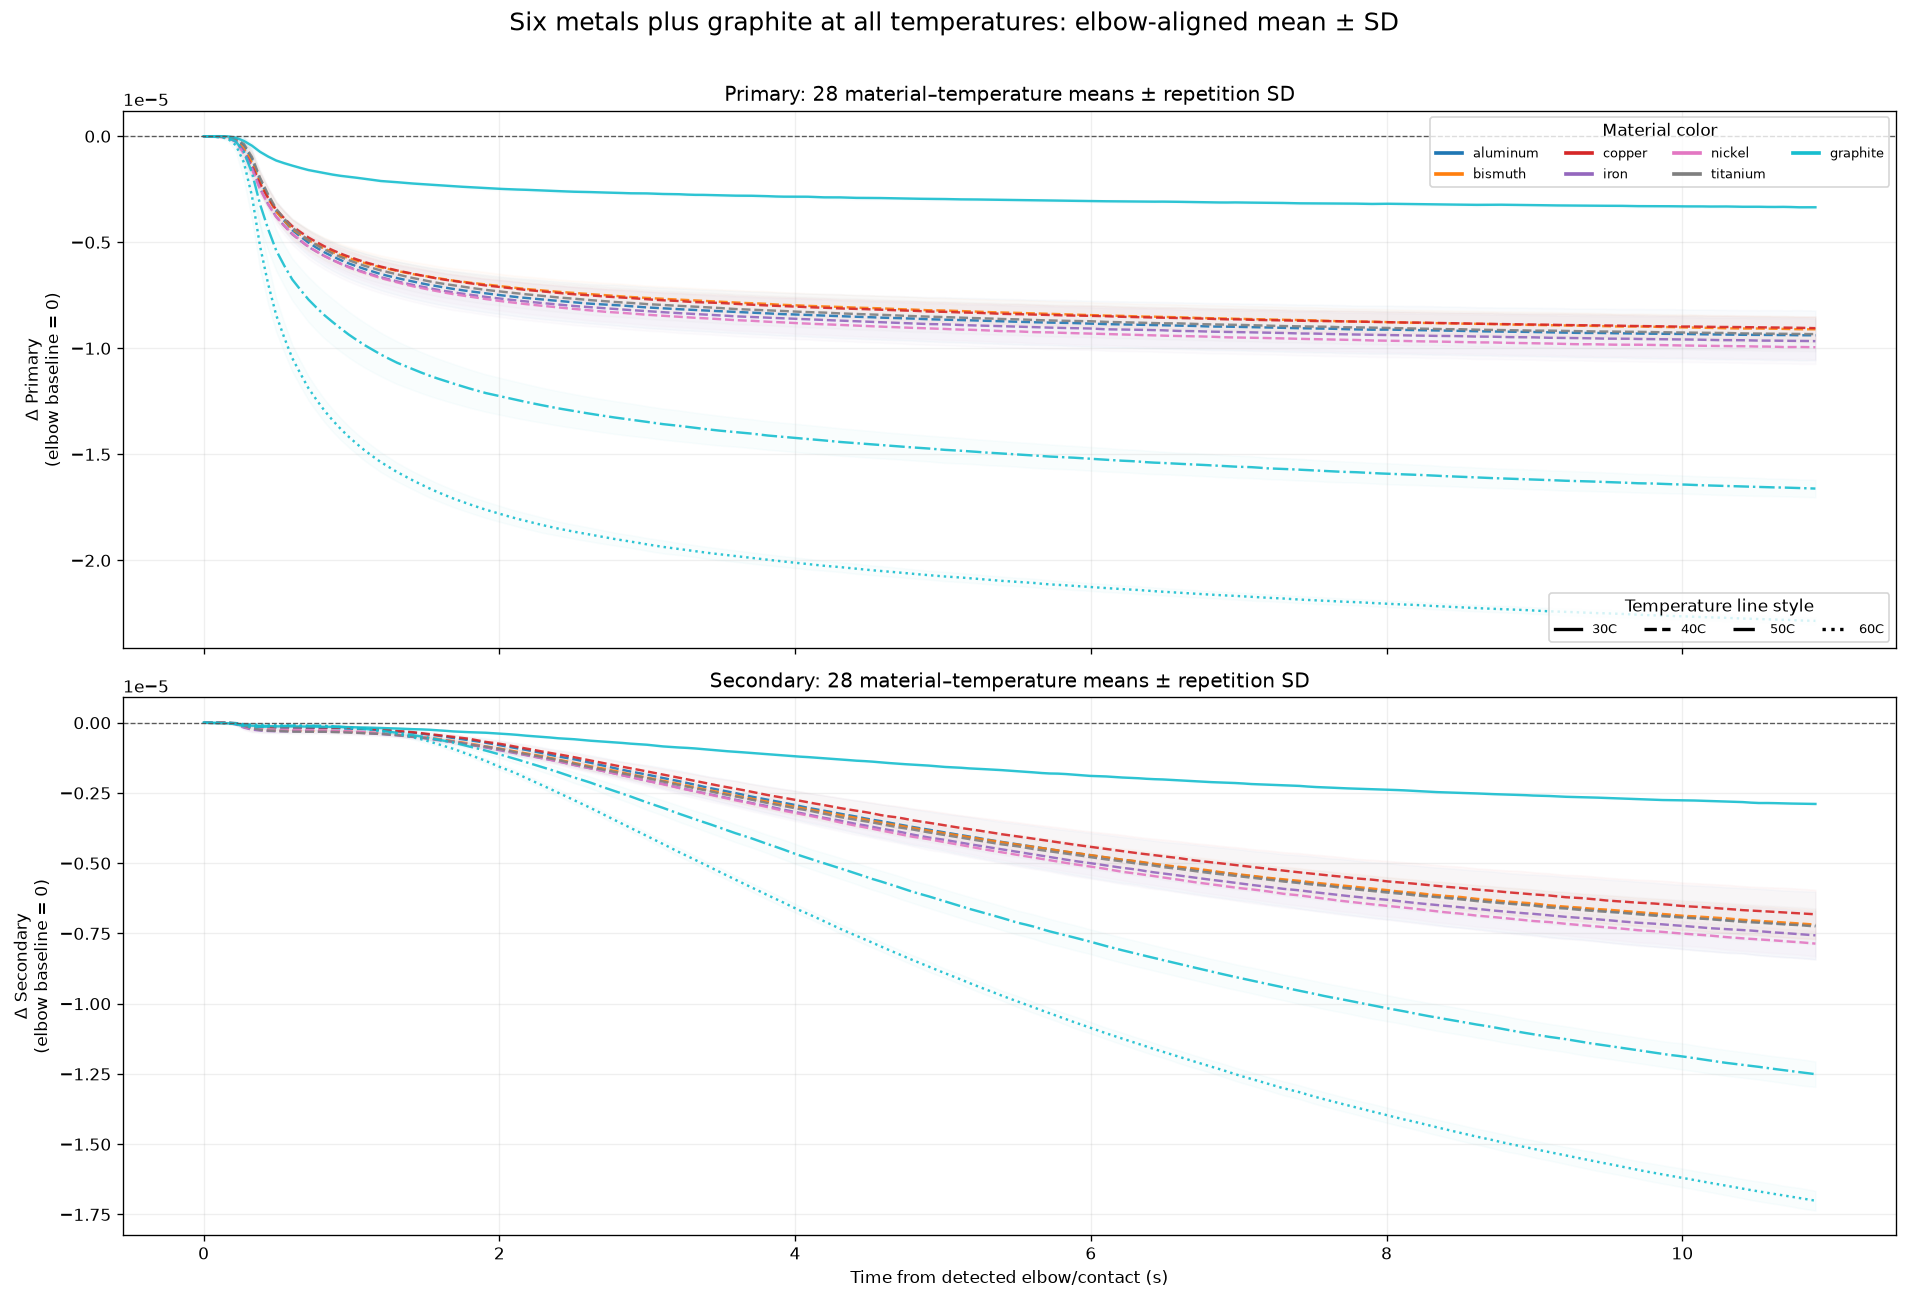

Common overlay duration: 10.900009999999998 s
Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/all_metals_graphite_all_temperatures_mean_sd.png


In [45]:
# Use a global duration supported by every retained trial.
trial_durations = DATA.groupby("trial_id")["time_from_elbow"].max()
COMMON_OVERLAY_END = float(trial_durations.min())
COMMON_OVERLAY_TIME = np.linspace(0.0, COMMON_OVERLAY_END, OVERLAY_TIME_POINTS)

material_colors = dict(zip(
    FOCUS_MATERIALS,
    plt.cm.tab10(np.linspace(0.0, 0.9, len(FOCUS_MATERIALS))),
))
temperature_styles = {
    "30C": "-",
    "40C": "--",
    "50C": "-.",
    "60C": ":",
}


def interpolate_aligned_trial(trial, sensor):
    trial = trial.sort_values("time_from_elbow")
    time = trial["time_from_elbow"].to_numpy(float)
    values = trial[f"{sensor}_aligned"].to_numpy(float)
    # Explicitly include the interpolated elbow origin when it lies between samples.
    if len(time) == 0 or not np.isclose(time[0], 0.0):
        time = np.insert(time, 0, 0.0)
        values = np.insert(values, 0, 0.0)
    return np.interp(COMMON_OVERLAY_TIME, time, values)


fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)

for sensor, axis in zip(SENSOR_COLUMNS, axes):
    for material in FOCUS_MATERIALS:
        for temperature in TEMPERATURE_FOLDERS:
            condition = DATA[
                (DATA["Sample"] == material)
                & (DATA["Temperature"] == temperature)
            ]
            repetitions = [
                interpolate_aligned_trial(trial, sensor)
                for _, trial in condition.groupby("trial_id", sort=True)
            ]
            if not repetitions:
                warnings.warn(f"No repetitions for {material} at {temperature}")
                continue
            matrix = np.vstack(repetitions)
            mean = matrix.mean(axis=0)
            sd = matrix.std(axis=0, ddof=1) if len(matrix) > 1 else np.zeros_like(mean)
            color = material_colors[material]
            linestyle = temperature_styles[temperature]
            axis.plot(
                COMMON_OVERLAY_TIME, mean,
                color=color, linestyle=linestyle, linewidth=1.45, alpha=0.90,
            )
            axis.fill_between(
                COMMON_OVERLAY_TIME, mean - sd, mean + sd,
                color=color, alpha=0.025,
            )

    axis.axhline(0, color="0.35", linestyle="--", linewidth=0.8)
    axis.set_ylabel(f"Δ {sensor}\n(elbow baseline = 0)")
    axis.set_title(f"{sensor}: 28 material–temperature means ± repetition SD")

axes[-1].set_xlabel("Time from detected elbow/contact (s)")

material_handles = [
    Line2D([0], [0], color=material_colors[m], linewidth=2.2, label=m)
    for m in FOCUS_MATERIALS
]
temperature_handles = [
    Line2D([0], [0], color="black", linestyle=temperature_styles[t], linewidth=2.0, label=t)
    for t in TEMPERATURE_FOLDERS
]
material_legend = axes[0].legend(
    handles=material_handles, title="Material color", ncol=4,
    loc="upper right", fontsize=8,
)
axes[0].add_artist(material_legend)
axes[0].legend(
    handles=temperature_handles, title="Temperature line style",
    ncol=4, loc="lower right", fontsize=8,
)

fig.suptitle(
    "Six metals plus graphite at all temperatures: elbow-aligned mean ± SD",
    fontsize=15,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
ALL_FOCUSED_OVERLAY_FIGURE = (
    OUTPUT_DIR / "all_metals_graphite_all_temperatures_mean_sd.png"
)
fig.savefig(ALL_FOCUSED_OVERLAY_FIGURE, dpi=220, bbox_inches="tight")
plt.show()

print("Common overlay duration:", COMMON_OVERLAY_END, "s")
print("Saved:", ALL_FOCUSED_OVERLAY_FIGURE)


# 5. Same-material comparison across all trials and temperatures

Each figure contains all 24 processed time series for one focused material:

\[
4	ext{ temperatures}	imes6	ext{ repetitions}=24	ext{ traces}.
\]

Every trial uses its detected elbow as the common time and signal reference. Consequently, all traces begin at contact with \(t=0\) and \(\Delta s=0\), allowing their post-contact response depths and timing to be compared directly. Primary and Secondary sensors are placed in separate panels. Color identifies temperature; line transparency keeps individual repetitions visible. A minimum marker is drawn on every trace.

Interpretation:

- baseline-centered curves reaching the same response depth indicate similar usable dynamic range; check the retained absolute-minimum analysis before calling this hardware saturation;
- a common floor across different focused materials is even stronger evidence;
- similar shapes with different absolute minima indicate response similarity, not necessarily saturation;
- isolated sharp minima without a plateau may be noise or an artifact rather than clipping.

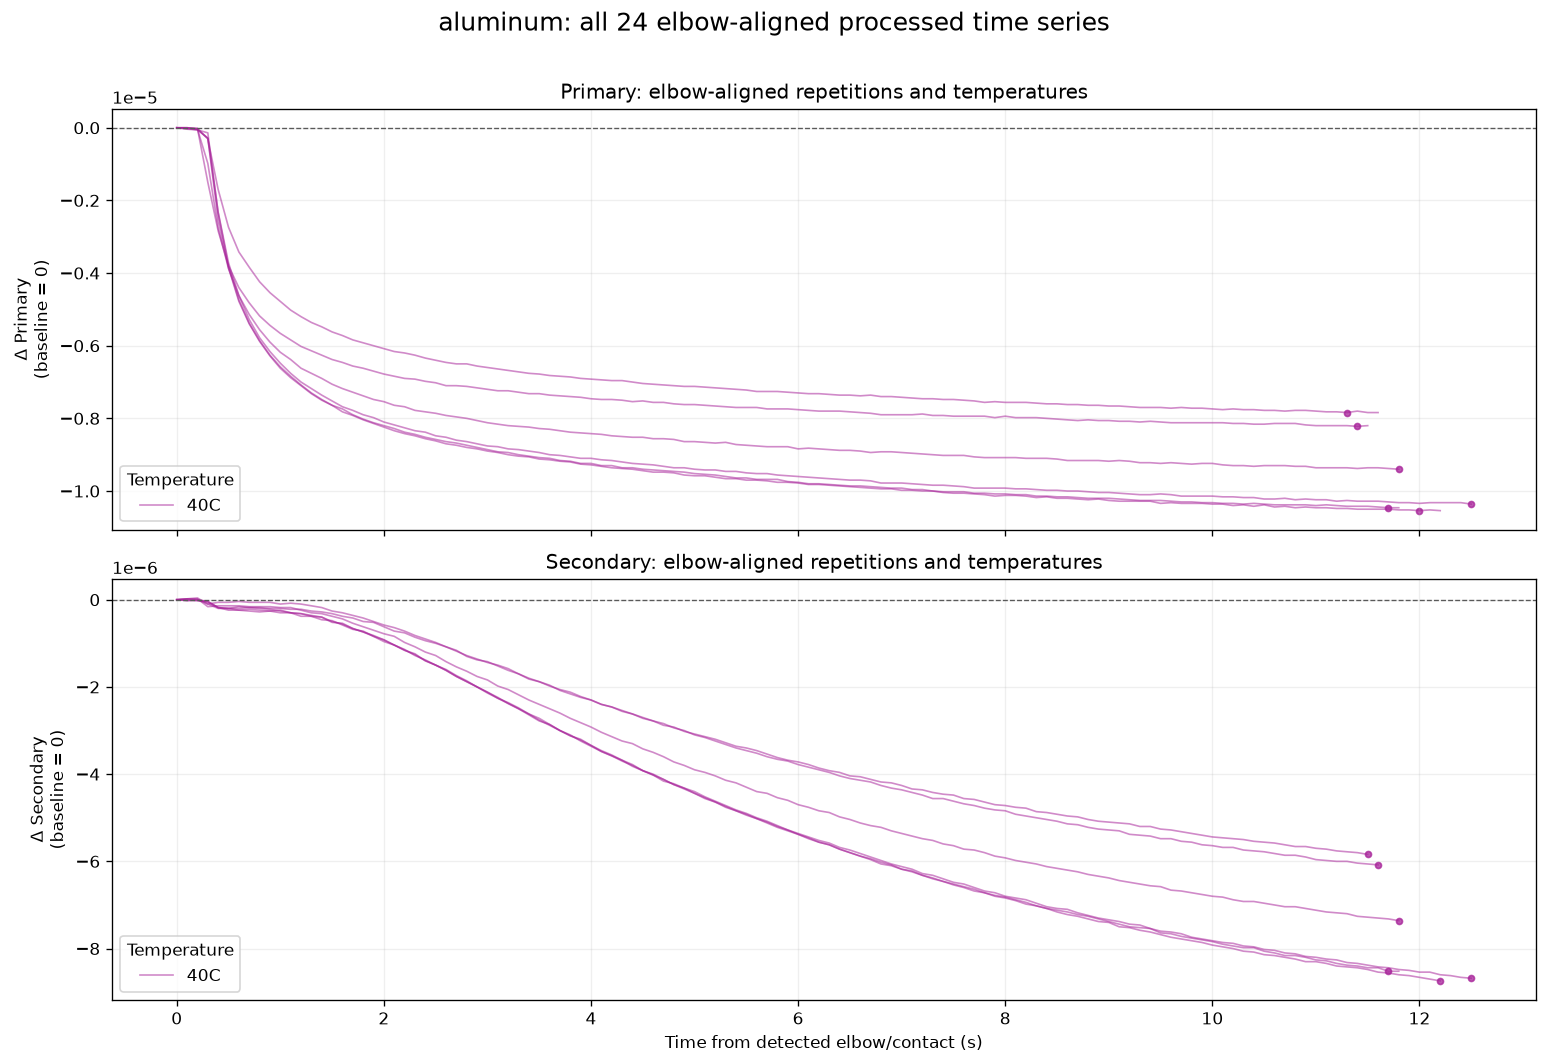

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/same_material_all_trials_temperatures_elbow_aligned_aluminum.png


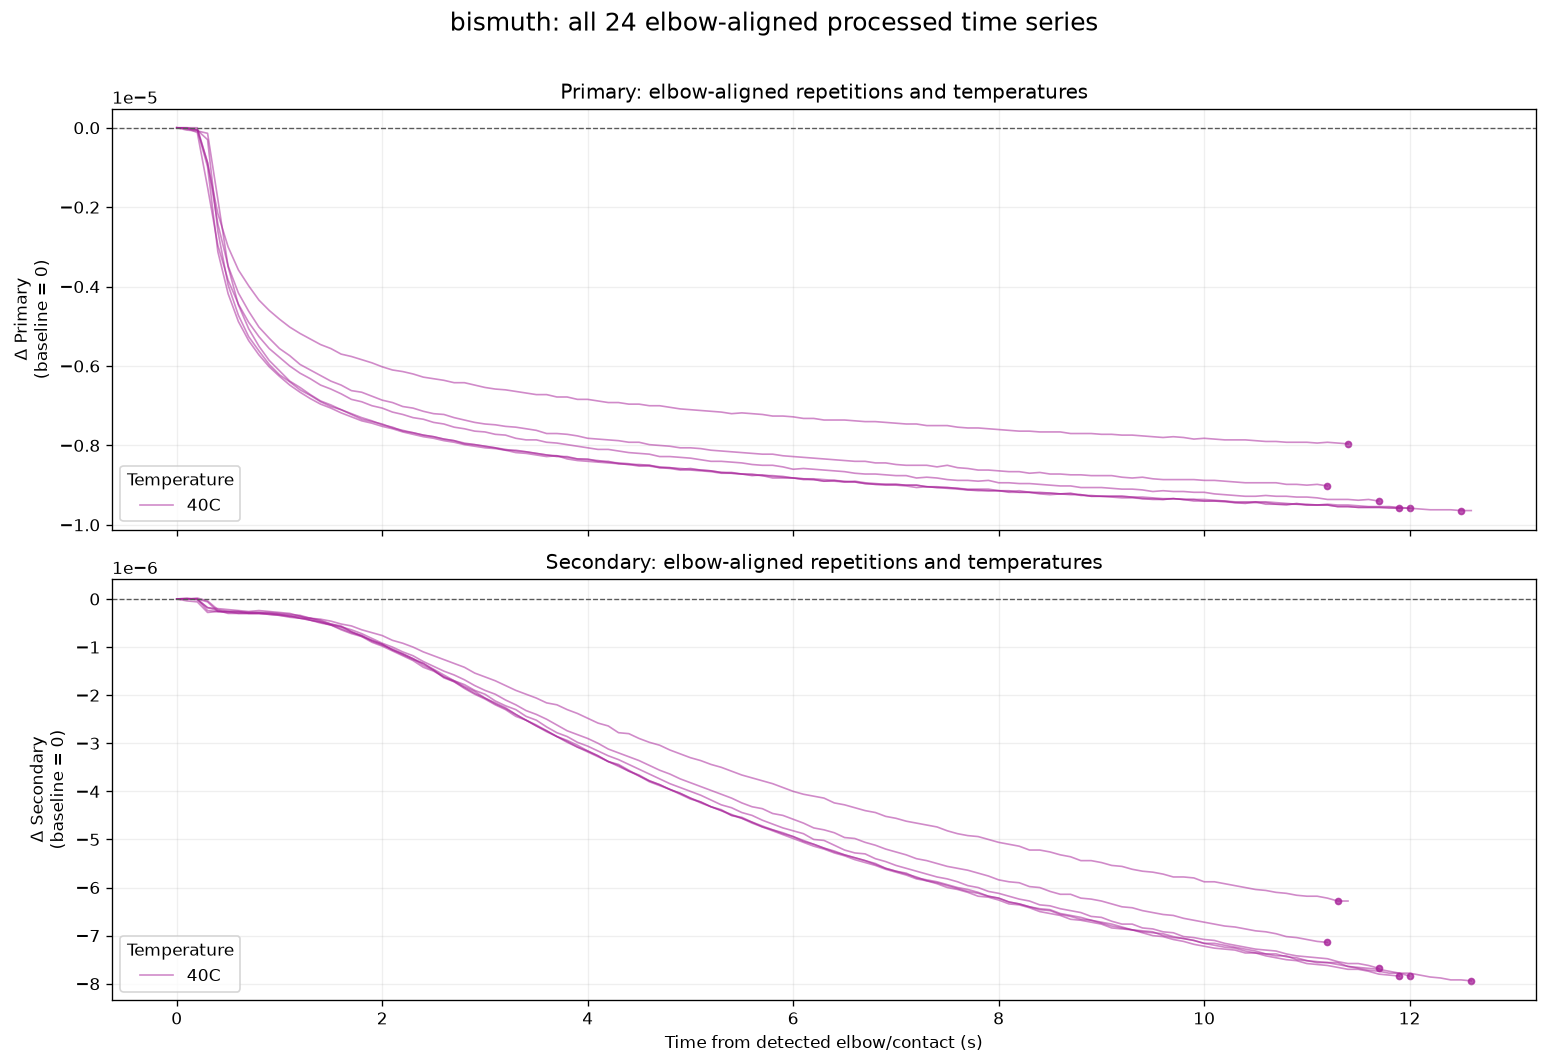

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/same_material_all_trials_temperatures_elbow_aligned_bismuth.png


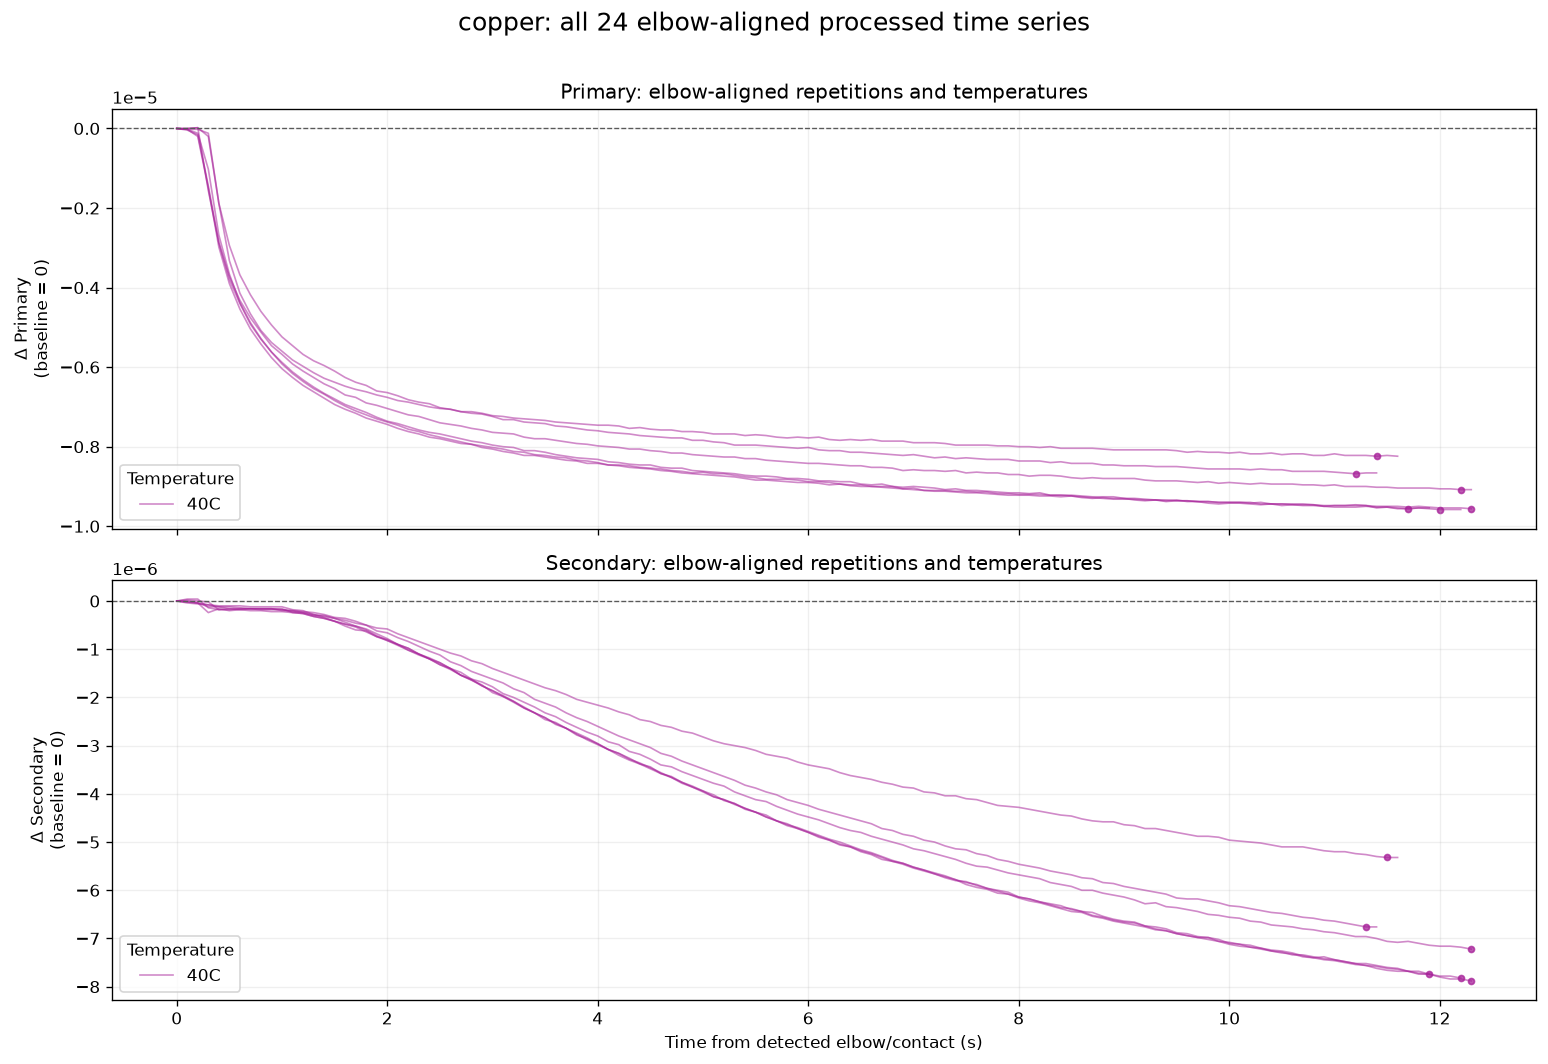

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/same_material_all_trials_temperatures_elbow_aligned_copper.png


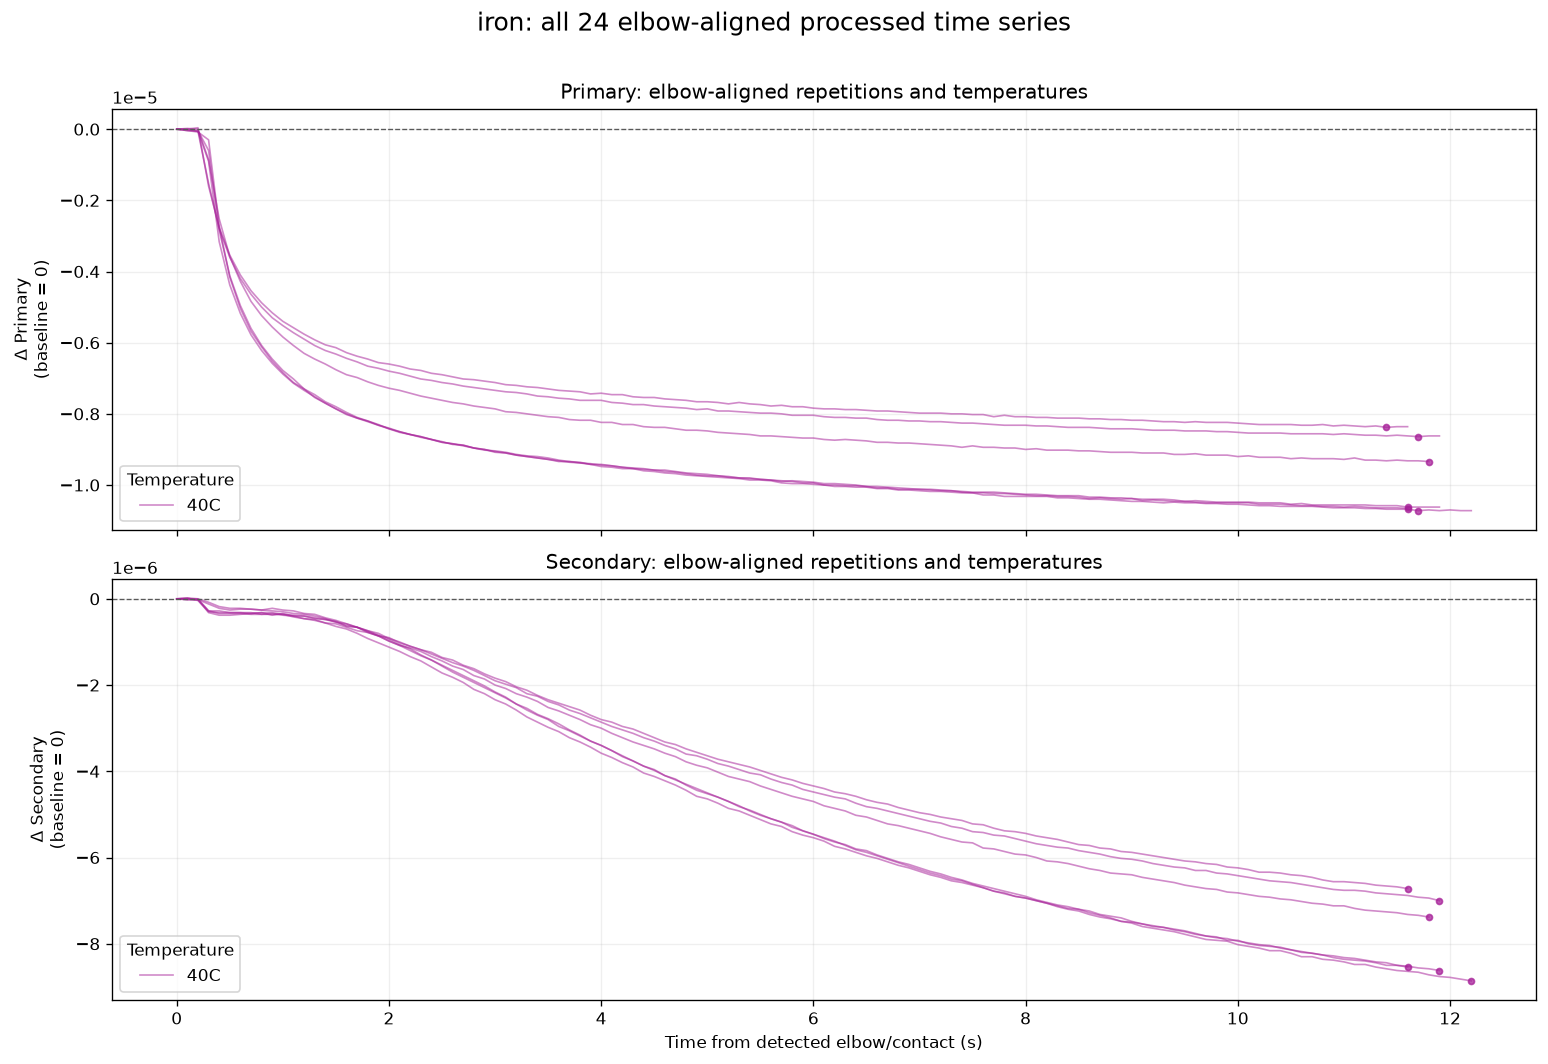

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/same_material_all_trials_temperatures_elbow_aligned_iron.png


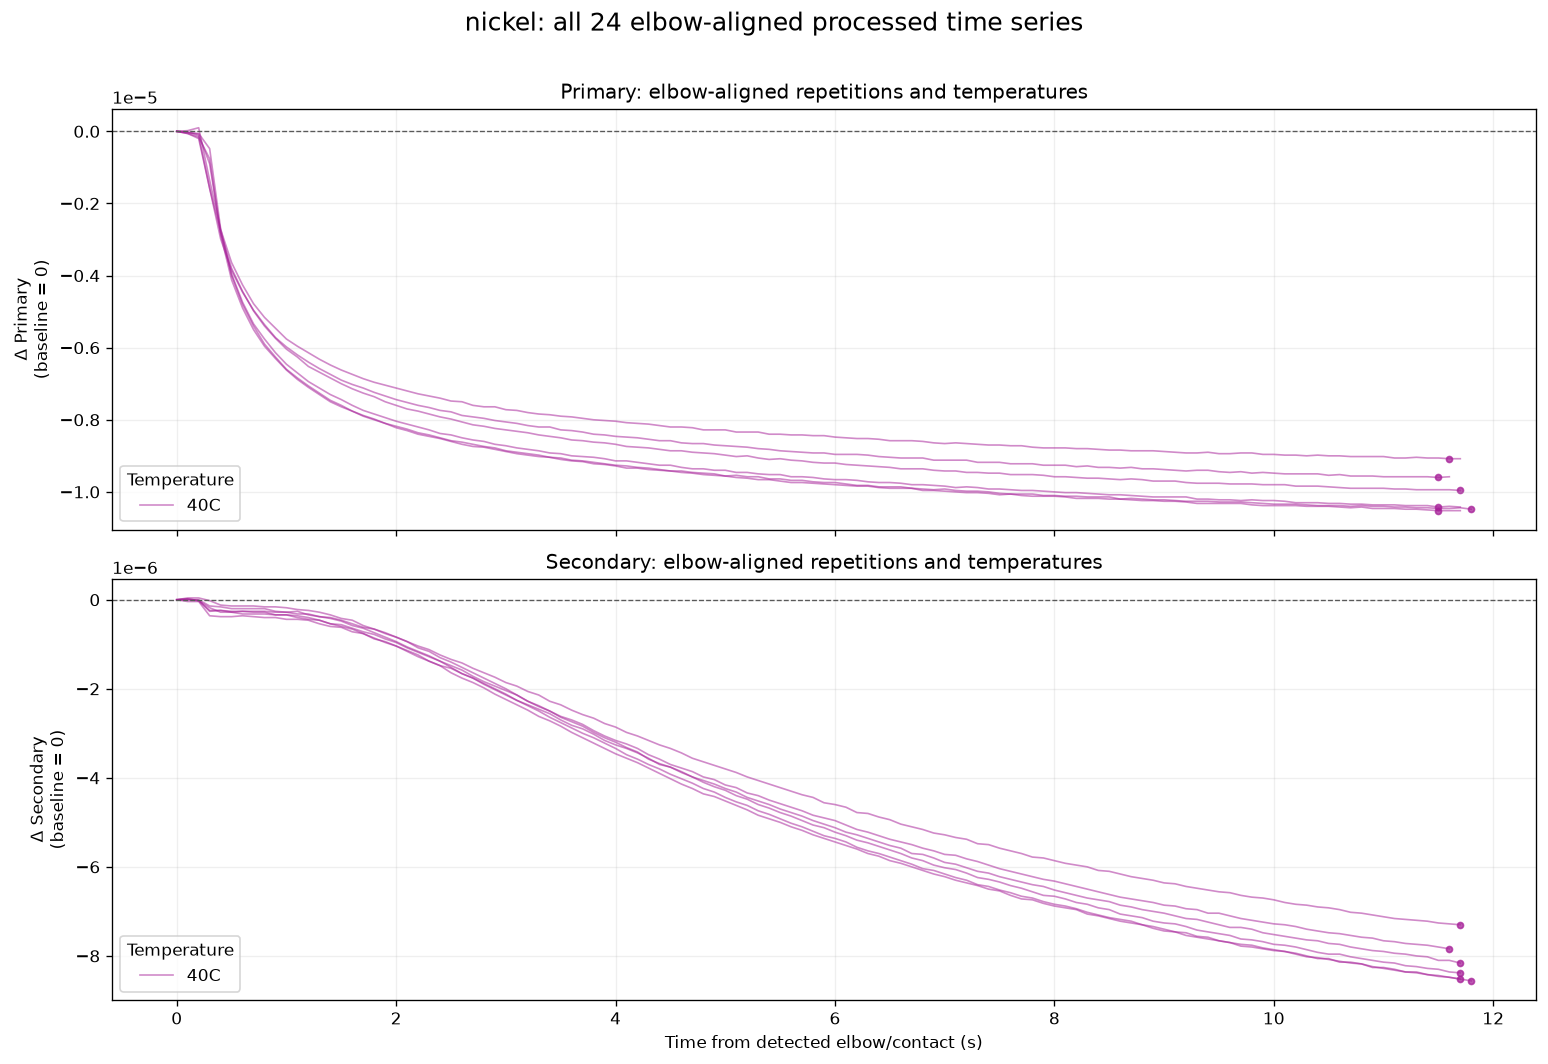

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/same_material_all_trials_temperatures_elbow_aligned_nickel.png


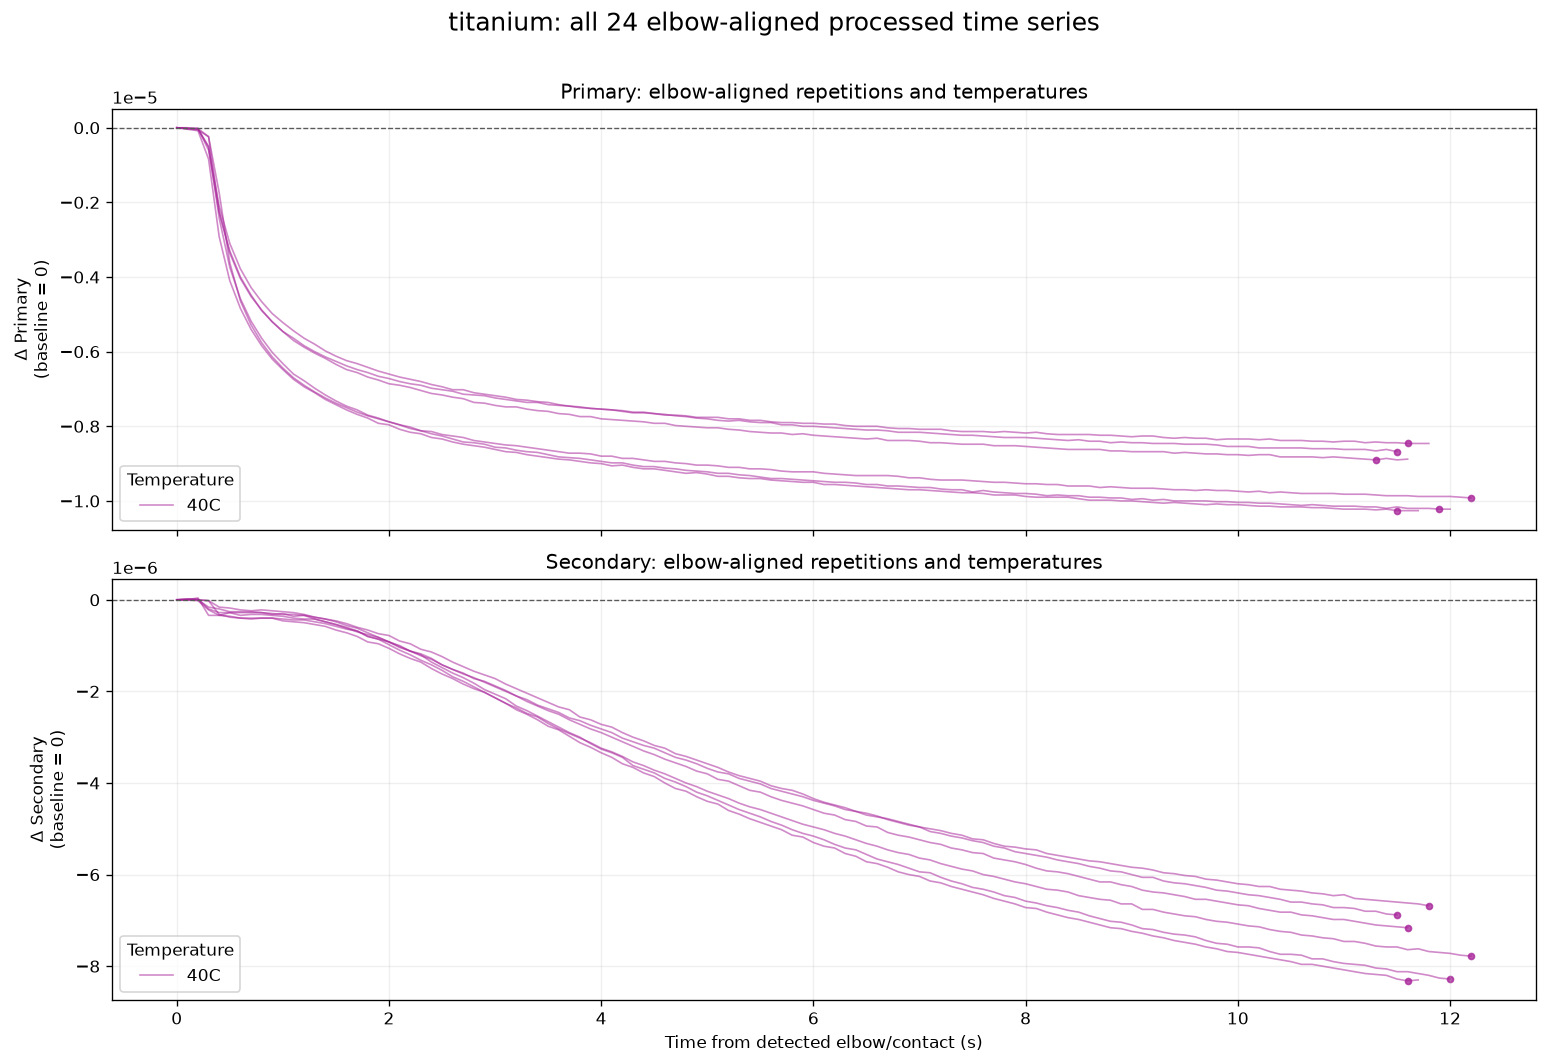

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/same_material_all_trials_temperatures_elbow_aligned_titanium.png


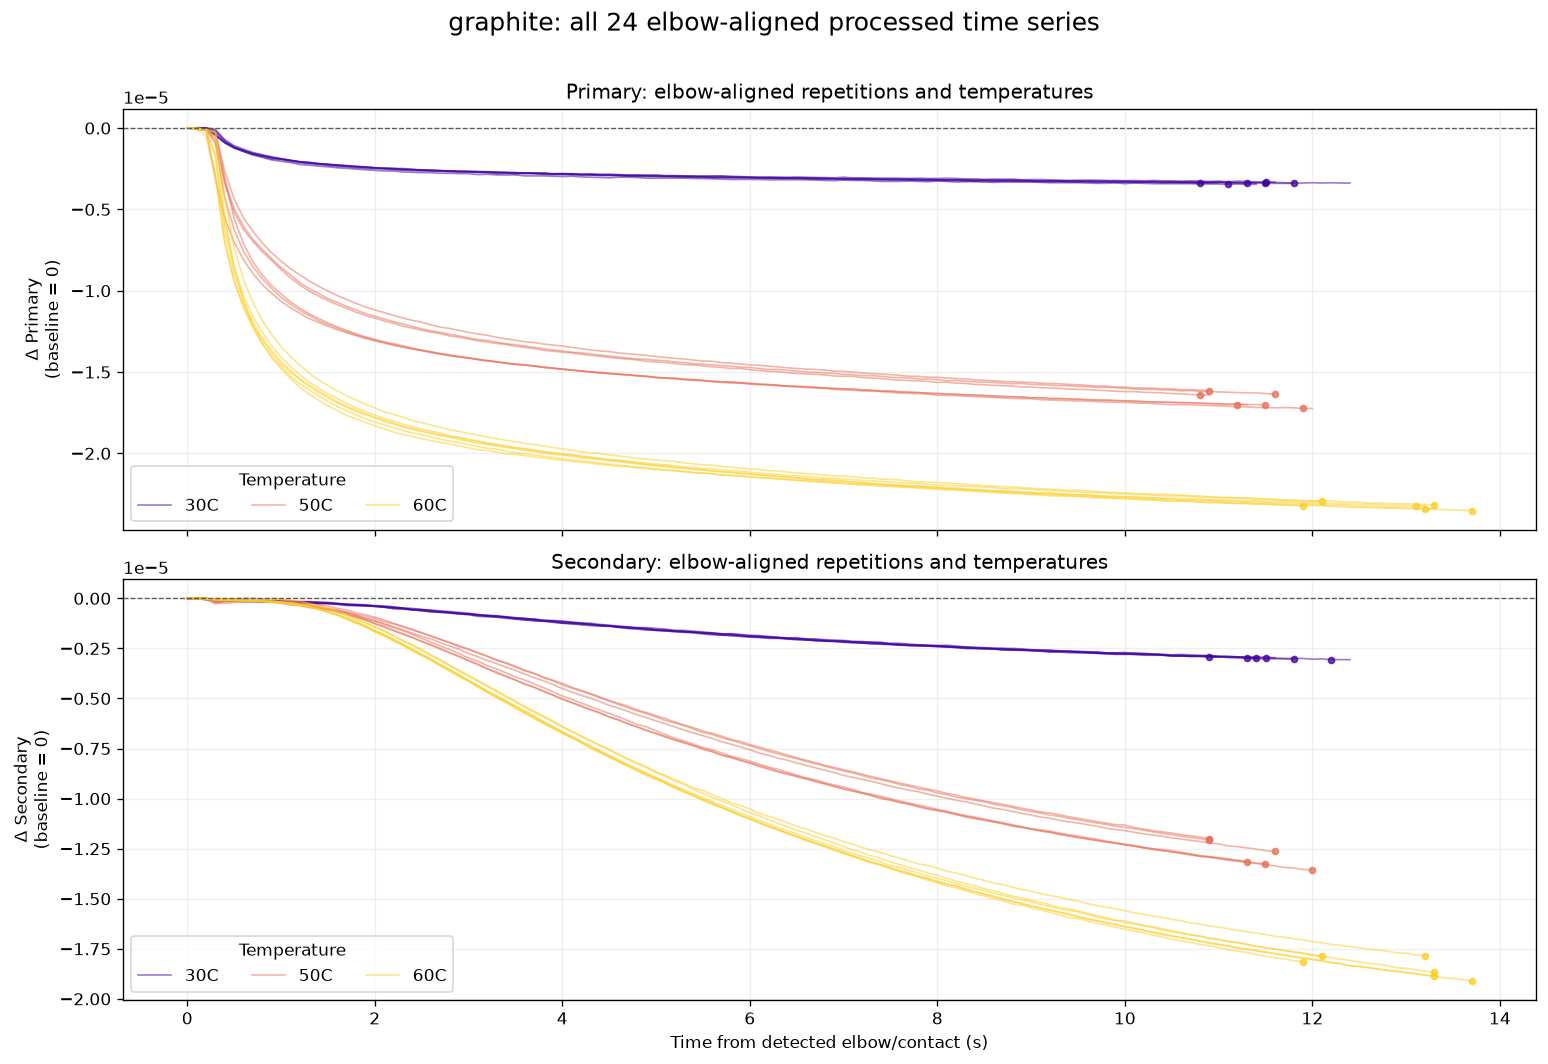

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/same_material_all_trials_temperatures_elbow_aligned_graphite.png


In [46]:
temperature_colors = dict(zip(
    TEMPERATURE_FOLDERS,
    plt.cm.plasma(np.linspace(0.10, 0.90, len(TEMPERATURE_FOLDERS))),
))
SAME_MATERIAL_FIGURES = []

for material in FOCUS_MATERIALS:
    material_data = DATA[DATA["Sample"] == material]
    fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

    for sensor, axis in zip(SENSOR_COLUMNS, axes):
        for temperature in TEMPERATURE_FOLDERS:
            temperature_data = material_data[material_data["Temperature"] == temperature]
            first_for_temperature = True
            for trial_id, trial in temperature_data.groupby("trial_id", sort=True):
                trial = trial.sort_values("Time")
                relative_time = trial["time_from_elbow"].to_numpy(float)
                values = trial[f"{sensor}_aligned"].to_numpy(float)
                # The elbow can lie between recorded samples. Prepend the
                # interpolated shared origin explicitly for visual comparison.
                if len(relative_time) == 0 or not np.isclose(relative_time[0], 0.0):
                    relative_time = np.insert(relative_time, 0, 0.0)
                    values = np.insert(values, 0, 0.0)
                minimum_index = int(np.argmin(values))
                axis.plot(
                    relative_time, values,
                    color=temperature_colors[temperature], alpha=0.52, linewidth=1.0,
                    label=temperature if first_for_temperature else None,
                )
                axis.scatter(
                    relative_time[minimum_index], values[minimum_index],
                    color=temperature_colors[temperature], s=13, alpha=0.75,
                )
                first_for_temperature = False

        axis.axhline(0, color="0.35", linestyle="--", linewidth=0.8)
        axis.set_ylabel(f"Δ {sensor}\n(baseline = 0)")
        axis.set_title(f"{sensor}: elbow-aligned repetitions and temperatures")
        axis.legend(title="Temperature", ncol=4, loc="best")

    axes[-1].set_xlabel("Time from detected elbow/contact (s)")
    fig.suptitle(
        f"{material}: all 24 elbow-aligned processed time series",
        fontsize=15,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    output = OUTPUT_DIR / f"same_material_all_trials_temperatures_elbow_aligned_{material}.png"
    fig.savefig(output, dpi=220, bbox_inches="tight")
    plt.show()
    SAME_MATERIAL_FIGURES.append(output)
    print("Saved:", output)


# 6. Calculate minimum and near-floor behavior for every trial

`near_min_fraction` is not proof of electronic clipping. It is a screening statistic: a high fraction or long consecutive run means the signal spends substantial time close to its observed minimum.

In [47]:
def longest_true_run(mask):
    longest = current = 0
    for value in np.asarray(mask, bool):
        current = current + 1 if value else 0
        longest = max(longest, current)
    return int(longest)


rows = []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time")
    base = {
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "n_samples": len(trial),
        "start_time": float(trial["Time"].iloc[0]),
        "end_time": float(trial["Time"].iloc[-1]),
    }
    for sensor in SENSOR_COLUMNS:
        values = trial[sensor].to_numpy(float)
        times = trial["time_from_elbow"].to_numpy(float)
        minimum_index = int(np.argmin(values))
        minimum = float(values[minimum_index])
        q05, q95 = np.quantile(values, [0.05, 0.95])
        tolerance = max(
            MINIMUM_ABSOLUTE_TOLERANCE,
            NEAR_MIN_RANGE_FRACTION * float(q95 - q05),
        )
        near_min = values <= minimum + tolerance
        baseline = float(trial[f"{sensor}_elbow_baseline"].iloc[0])
        centered = trial[f"{sensor}_aligned"].to_numpy(float)
        prefix = sensor.lower()
        base.update({
            f"{prefix}_minimum": minimum,
            f"{prefix}_minimum_time": float(times[minimum_index]),
            f"{prefix}_baseline": baseline,
            f"{prefix}_centered_minimum": float(np.min(centered)),
            f"{prefix}_q01": float(np.quantile(values, 0.01)),
            f"{prefix}_q05": float(q05),
            f"{prefix}_near_min_tolerance": tolerance,
            f"{prefix}_near_min_fraction": float(np.mean(near_min)),
            f"{prefix}_longest_near_min_run": longest_true_run(near_min),
            f"{prefix}_longest_near_min_fraction": longest_true_run(near_min) / len(values),
        })
    rows.append(base)

TRIAL_MINIMA = pd.DataFrame(rows)
TRIAL_MINIMA.to_csv(OUTPUT_DIR / "all_trial_sensor_minima.csv", index=False)
print("Per-trial results:", len(TRIAL_MINIMA))
display(TRIAL_MINIMA.head())


Per-trial results: 54


,trial_id,Temperature,Sample,Trial,n_samples,start_time,end_time,primary_minimum,primary_minimum_time,primary_baseline,...,secondary_minimum,secondary_minimum_time,secondary_baseline,secondary_centered_minimum,secondary_q01,secondary_q05,secondary_near_min_tolerance,secondary_near_min_fraction,secondary_longest_near_min_run,secondary_longest_near_min_fraction
0,30C__graphite_trial_1,30C,graphite,1,111,8.60070,19.60070,0.000656,10.80000,0.000659,...,0.000697,10.89996,0.0007,-0.000003,0.000697,0.000697,5.460000e-08,0.027027,2,0.018018
1,30C__graphite_trial_2,30C,graphite,2,115,7.50066,18.90070,0.000656,11.30000,0.000659,...,0.000697,11.30000,0.0007,-0.000003,0.000697,0.000697,5.480000e-08,0.043478,5,0.043478
2,30C__graphite_trial_3,30C,graphite,3,119,7.90070,19.70070,0.000656,11.49996,0.000659,...,0.000697,11.80000,0.0007,-0.000003,0.000697,0.000697,5.648000e-08,0.050420,6,0.050420
3,30C__graphite_trial_4,30C,graphite,4,117,7.60066,19.20066,0.000656,11.50004,0.000659,...,0.000697,11.50004,0.0007,-0.000003,0.000697,0.000697,5.560000e-08,0.042735,5,0.042735
4,30C__graphite_trial_5,30C,graphite,5,115,8.00066,19.40066,0.000656,11.10000,0.000659,...,0.000697,11.40000,0.0007,-0.000003,0.000697,0.000697,5.532000e-08,0.026087,3,0.026087


# 7. Lowest recorded trials

In [48]:
for sensor in SENSOR_COLUMNS:
    prefix = sensor.lower()
    columns = [
        "Temperature", "Sample", "Trial", "n_samples",
        f"{prefix}_minimum", f"{prefix}_centered_minimum",
        f"{prefix}_minimum_time", f"{prefix}_near_min_fraction",
        f"{prefix}_longest_near_min_fraction",
    ]
    ordered = TRIAL_MINIMA.sort_values(f"{prefix}_minimum")[columns]
    if LOWEST_TRIALS_TO_DISPLAY is not None:
        ordered = ordered.head(LOWEST_TRIALS_TO_DISPLAY)
    print(f"Lowest {sensor} trials:")
    display(ordered)


Lowest Primary trials:


,Temperature,Sample,Trial,n_samples,primary_minimum,primary_centered_minimum,primary_minimum_time,primary_near_min_fraction,primary_longest_near_min_fraction
51,60C,graphite,4,120,0.000635,-0.000023,11.89996,0.091667,0.083333
50,60C,graphite,3,134,0.000635,-0.000023,13.20000,0.089552,0.089552
49,60C,graphite,2,138,0.000635,-0.000024,13.70000,0.101449,0.101449
53,60C,graphite,6,133,0.000635,-0.000023,13.10000,0.105263,0.105263
52,60C,graphite,5,122,0.000635,-0.000023,12.10004,0.114754,0.114754
48,60C,graphite,1,134,0.000635,-0.000023,13.30000,0.104478,0.104478
46,50C,graphite,5,121,0.000643,-0.000017,11.89996,0.099174,0.099174
47,50C,graphite,6,114,0.000643,-0.000017,11.20000,0.105263,0.105263
42,50C,graphite,1,116,0.000643,-0.000017,11.49996,0.112069,0.112069
45,50C,graphite,4,117,0.000643,-0.000016,11.60004,0.085470,0.076923


Lowest Secondary trials:


,Temperature,Sample,Trial,n_samples,secondary_minimum,secondary_centered_minimum,secondary_minimum_time,secondary_near_min_fraction,secondary_longest_near_min_fraction
49,60C,graphite,2,138,0.000680,-0.000019,13.70000,0.050725,0.050725
50,60C,graphite,3,134,0.000680,-0.000019,13.30000,0.052239,0.052239
48,60C,graphite,1,134,0.000680,-0.000019,13.30000,0.044776,0.044776
51,60C,graphite,4,120,0.000681,-0.000018,11.89996,0.041667,0.041667
52,60C,graphite,5,122,0.000681,-0.000018,12.10004,0.040984,0.040984
53,60C,graphite,6,133,0.000681,-0.000018,13.20000,0.052632,0.052632
46,50C,graphite,5,121,0.000685,-0.000014,11.99996,0.049587,0.049587
47,50C,graphite,6,114,0.000686,-0.000013,11.30000,0.035088,0.035088
42,50C,graphite,1,116,0.000686,-0.000013,11.49996,0.043103,0.043103
45,50C,graphite,4,117,0.000686,-0.000013,11.60004,0.042735,0.042735


# 8. Material–temperature summary tables

In [49]:
aggregations = {}
for sensor in SENSOR_COLUMNS:
    prefix = sensor.lower()
    aggregations.update({
        f"{prefix}_minimum_mean": (f"{prefix}_minimum", "mean"),
        f"{prefix}_minimum_sd": (f"{prefix}_minimum", "std"),
        f"{prefix}_minimum_across_trials": (f"{prefix}_minimum", "min"),
        f"{prefix}_centered_minimum_mean": (f"{prefix}_centered_minimum", "mean"),
        f"{prefix}_near_min_fraction_mean": (f"{prefix}_near_min_fraction", "mean"),
        f"{prefix}_longest_near_min_fraction_mean": (f"{prefix}_longest_near_min_fraction", "mean"),
    })

MATERIAL_TEMPERATURE_SUMMARY = (
    TRIAL_MINIMA.groupby(["Sample", "Temperature"], as_index=False)
    .agg(**aggregations)
)
MATERIAL_TEMPERATURE_SUMMARY.to_csv(
    OUTPUT_DIR / "material_temperature_sensor_minimum_summary.csv", index=False
)

material_order = (
    TRIAL_MINIMA.groupby("Sample")["primary_minimum"].mean().sort_values().index
)
display(MATERIAL_TEMPERATURE_SUMMARY)


,Sample,Temperature,primary_minimum_mean,primary_minimum_sd,primary_minimum_across_trials,primary_centered_minimum_mean,primary_near_min_fraction_mean,primary_longest_near_min_fraction_mean,secondary_minimum_mean,secondary_minimum_sd,secondary_minimum_across_trials,secondary_centered_minimum_mean,secondary_near_min_fraction_mean,secondary_longest_near_min_fraction_mean
0,aluminum,40C,0.000649,2.782804e-07,0.000649,-0.000009,0.112312,0.103858,0.000690,4.638534e-07,0.000689,-0.000008,0.044412,0.044412
1,bismuth,40C,0.000650,2.587405e-07,0.000650,-0.000009,0.086684,0.085295,0.000691,4.915960e-07,0.000690,-0.000007,0.044778,0.044778
2,copper,40C,0.000650,3.186011e-07,0.000649,-0.000009,0.117576,0.114703,0.000691,8.980572e-07,0.000689,-0.000007,0.044228,0.044228
3,graphite,30C,0.000656,4.273952e-08,0.000656,-0.000003,0.079857,0.059892,0.000697,7.201852e-08,0.000697,-0.000003,0.038291,0.036790
4,graphite,50C,0.000643,3.547205e-07,0.000643,-0.000017,0.098814,0.097390,0.000686,5.751753e-07,0.000685,-0.000013,0.040540,0.040540
5,graphite,60C,0.000635,1.680079e-07,0.000635,-0.000023,0.101194,0.099805,0.000680,4.456755e-07,0.000680,-0.000018,0.047170,0.047170
6,iron,40C,0.000649,2.239345e-07,0.000649,-0.000010,0.120061,0.120061,0.000690,6.953177e-07,0.000689,-0.000008,0.041947,0.041947
7,nickel,40C,0.000649,1.955505e-07,0.000649,-0.000010,0.117247,0.115834,0.000690,6.362913e-07,0.000689,-0.000008,0.045199,0.045199
8,titanium,40C,0.000650,2.063008e-07,0.000649,-0.000009,0.109131,0.107753,0.000691,7.795127e-07,0.000690,-0.000008,0.041975,0.040620


# 9. Minimum-value heatmaps

If many metals have nearly identical absolute minima across temperatures, inspect Section 8 for plateaus and raw traces before concluding that the sensor is saturated.

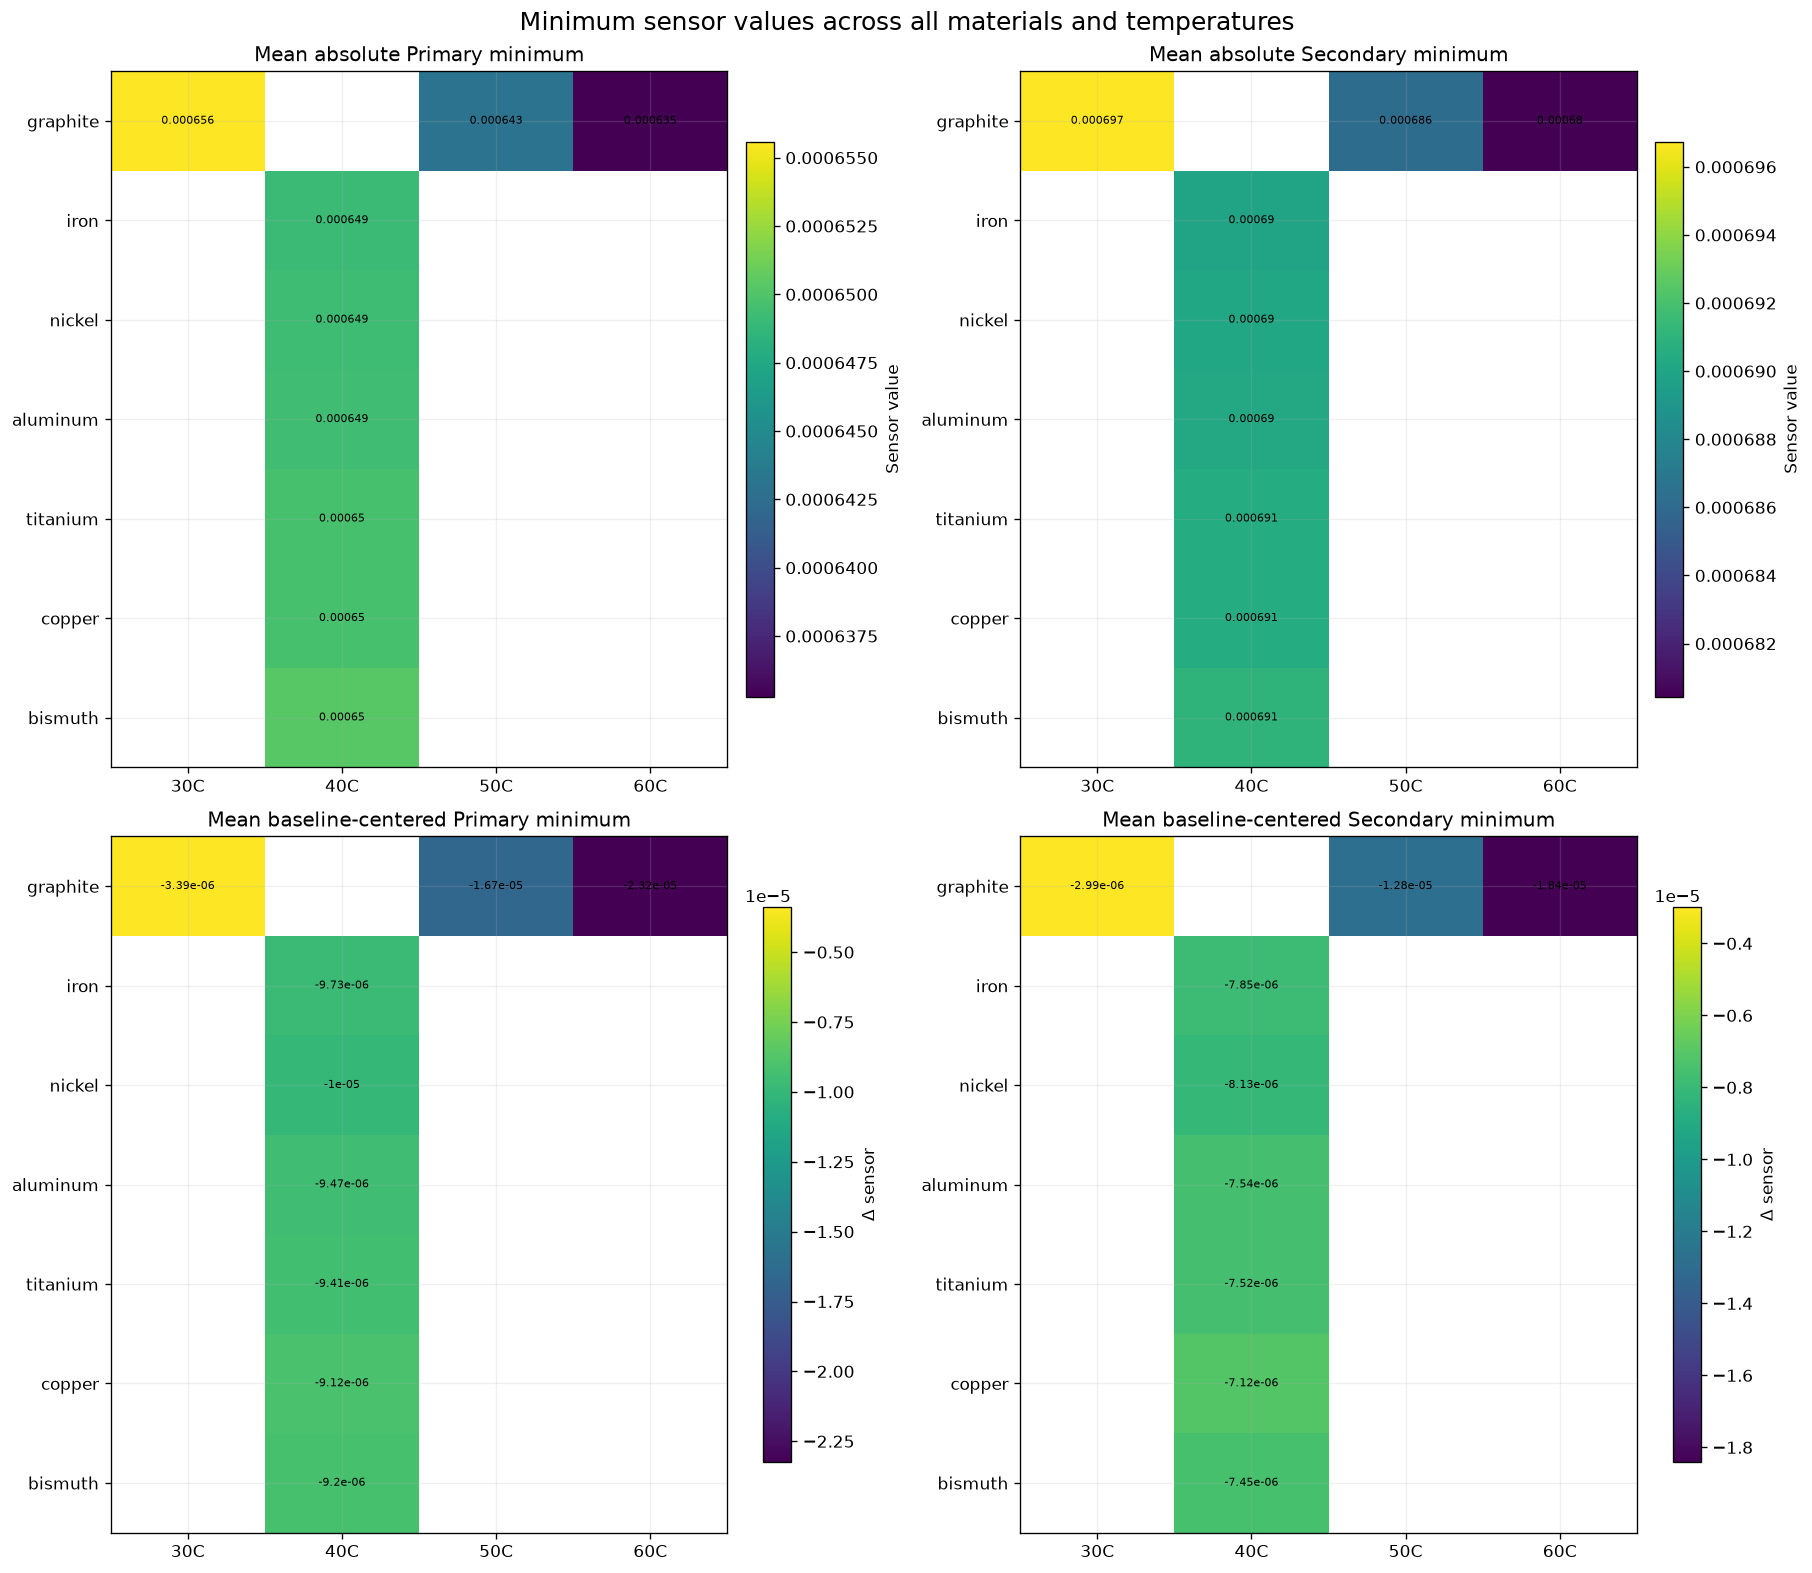

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/sensor_minimum_heatmaps.png


In [50]:
def heatmap(axis, column, title, colorbar_label, fmt=".3g"):
    table = (
        MATERIAL_TEMPERATURE_SUMMARY.pivot(
            index="Sample", columns="Temperature", values=column
        ).reindex(index=material_order, columns=TEMPERATURE_FOLDERS)
    )
    image = axis.imshow(table, aspect="auto", cmap="viridis")
    axis.set_xticks(np.arange(len(table.columns)), table.columns)
    axis.set_yticks(np.arange(len(table.index)), table.index)
    axis.set_title(title)
    for row in range(table.shape[0]):
        for column_index in range(table.shape[1]):
            value = table.iloc[row, column_index]
            if np.isfinite(value):
                axis.text(column_index, row, format(value, fmt), ha="center", va="center", fontsize=6.5)
    colorbar = axis.figure.colorbar(image, ax=axis, fraction=0.045, pad=0.03)
    colorbar.set_label(colorbar_label)
    return table


fig, axes = plt.subplots(2, 2, figsize=(15, 13), constrained_layout=True)
PRIMARY_MINIMUM_MATRIX = heatmap(
    axes[0, 0], "primary_minimum_mean", "Mean absolute Primary minimum", "Sensor value"
)
SECONDARY_MINIMUM_MATRIX = heatmap(
    axes[0, 1], "secondary_minimum_mean", "Mean absolute Secondary minimum", "Sensor value"
)
heatmap(
    axes[1, 0], "primary_centered_minimum_mean",
    "Mean baseline-centered Primary minimum", "Δ sensor"
)
heatmap(
    axes[1, 1], "secondary_centered_minimum_mean",
    "Mean baseline-centered Secondary minimum", "Δ sensor"
)
fig.suptitle("Minimum sensor values across all materials and temperatures", fontsize=15)
MINIMUM_HEATMAP = OUTPUT_DIR / "sensor_minimum_heatmaps.png"
fig.savefig(MINIMUM_HEATMAP, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", MINIMUM_HEATMAP)


# 10. Near-minimum plateau screening

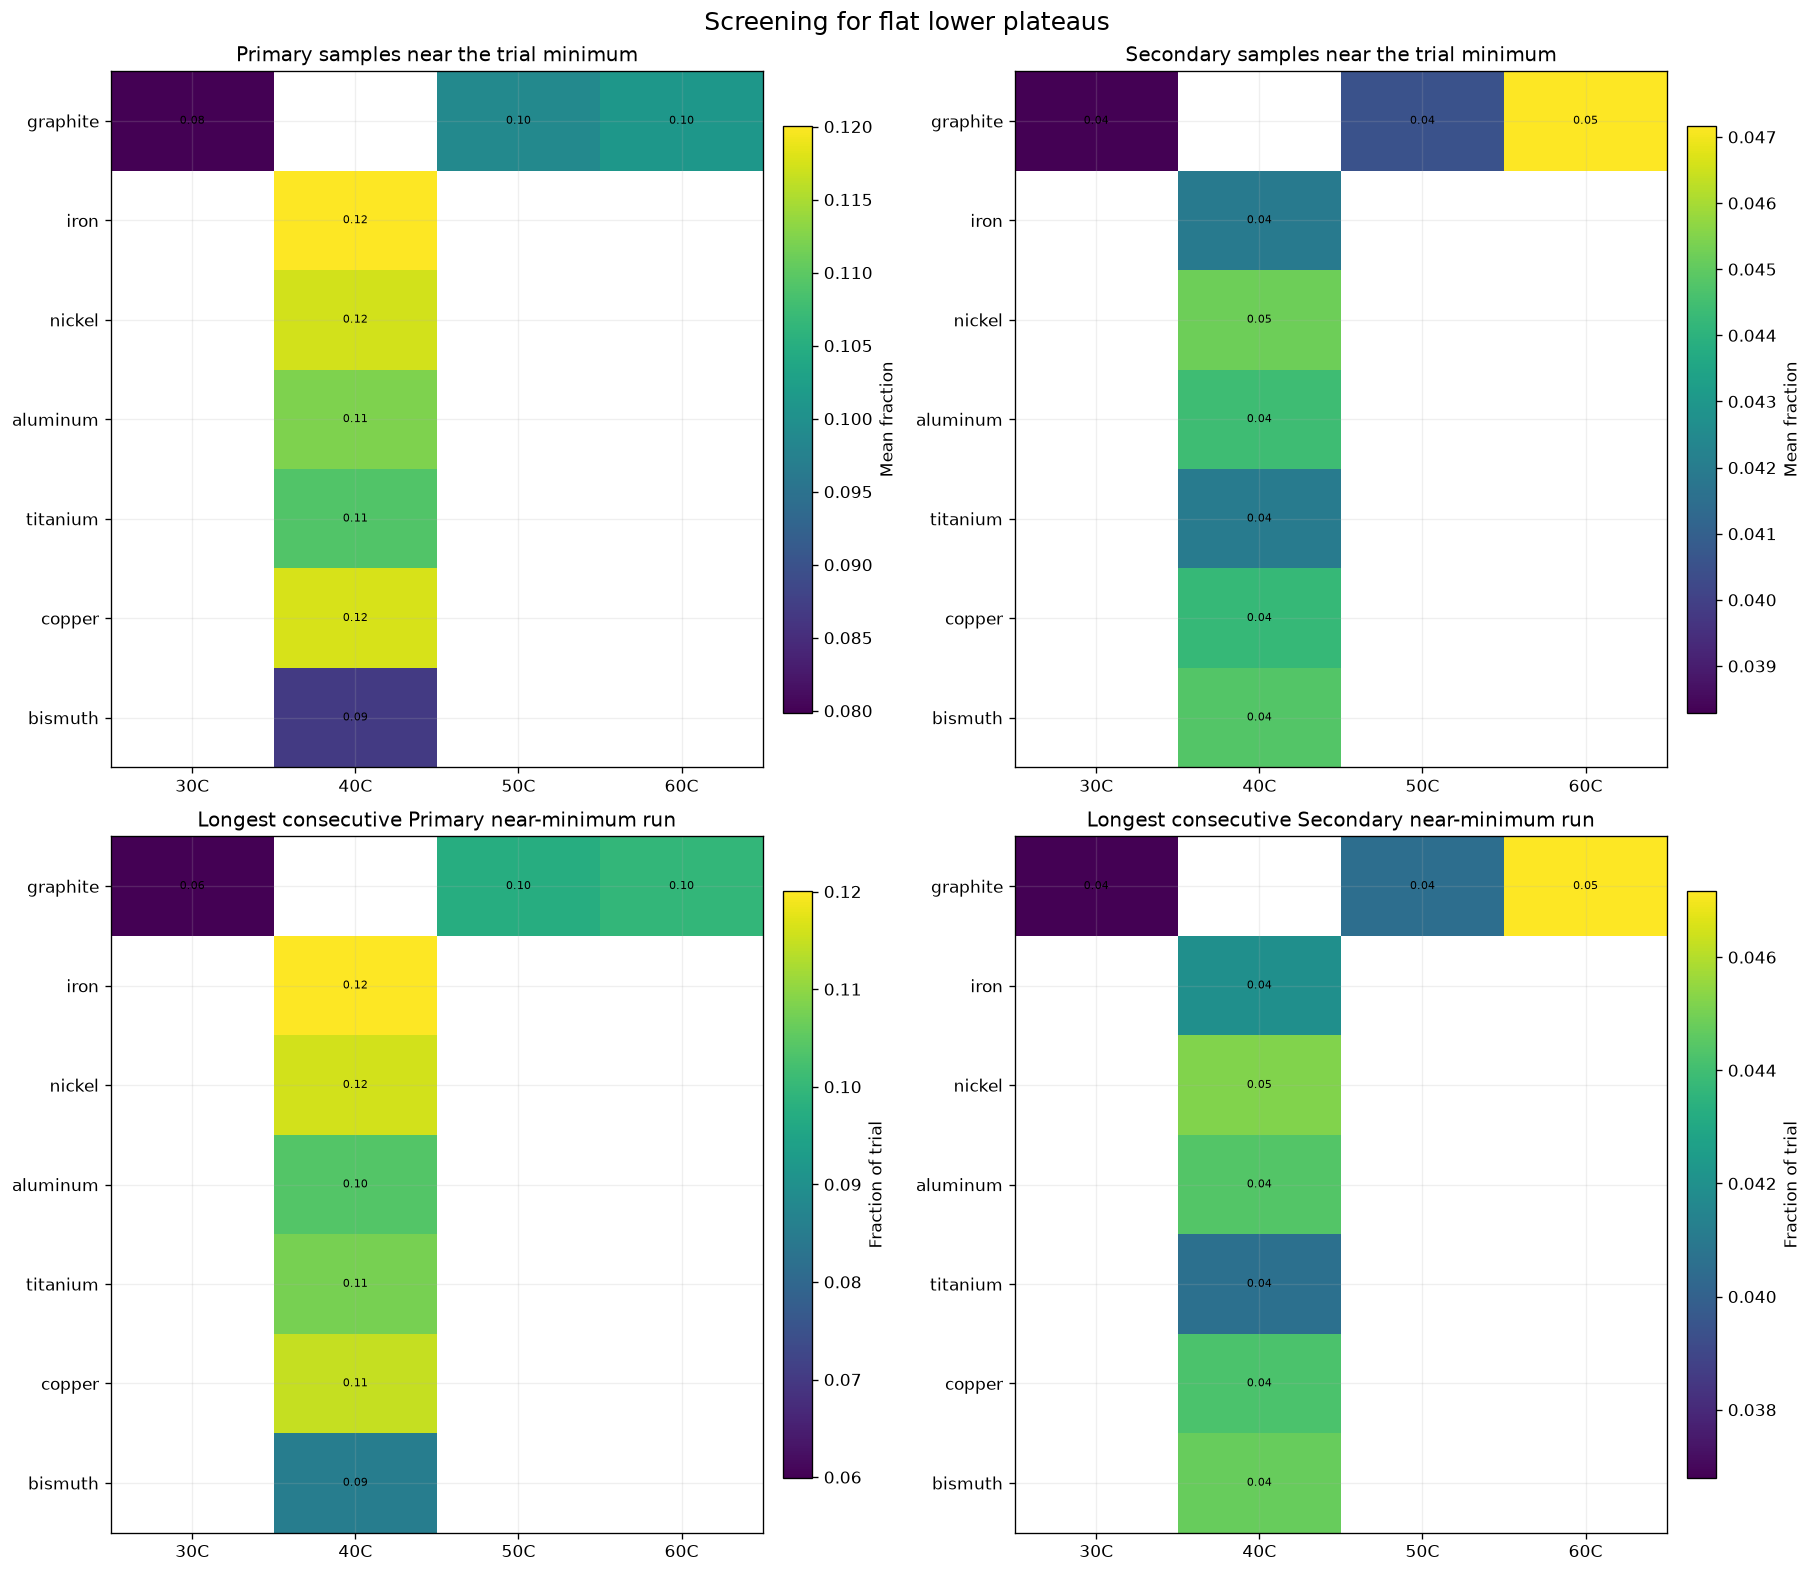

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/near_minimum_plateau_heatmaps.png


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13), constrained_layout=True)
heatmap(
    axes[0, 0], "primary_near_min_fraction_mean",
    "Primary samples near the trial minimum", "Mean fraction", fmt=".2f"
)
heatmap(
    axes[0, 1], "secondary_near_min_fraction_mean",
    "Secondary samples near the trial minimum", "Mean fraction", fmt=".2f"
)
heatmap(
    axes[1, 0], "primary_longest_near_min_fraction_mean",
    "Longest consecutive Primary near-minimum run", "Fraction of trial", fmt=".2f"
)
heatmap(
    axes[1, 1], "secondary_longest_near_min_fraction_mean",
    "Longest consecutive Secondary near-minimum run", "Fraction of trial", fmt=".2f"
)
fig.suptitle("Screening for flat lower plateaus", fontsize=15)
PLATEAU_HEATMAP = OUTPUT_DIR / "near_minimum_plateau_heatmaps.png"
fig.savefig(PLATEAU_HEATMAP, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", PLATEAU_HEATMAP)


# 11. Inspect raw traces with the lowest minima

These traces help distinguish a genuine asymptotic thermal response from clipping. Electronic or preprocessing saturation is more plausible when different trials reach exactly or nearly the same floor and remain flat there for multiple consecutive samples.

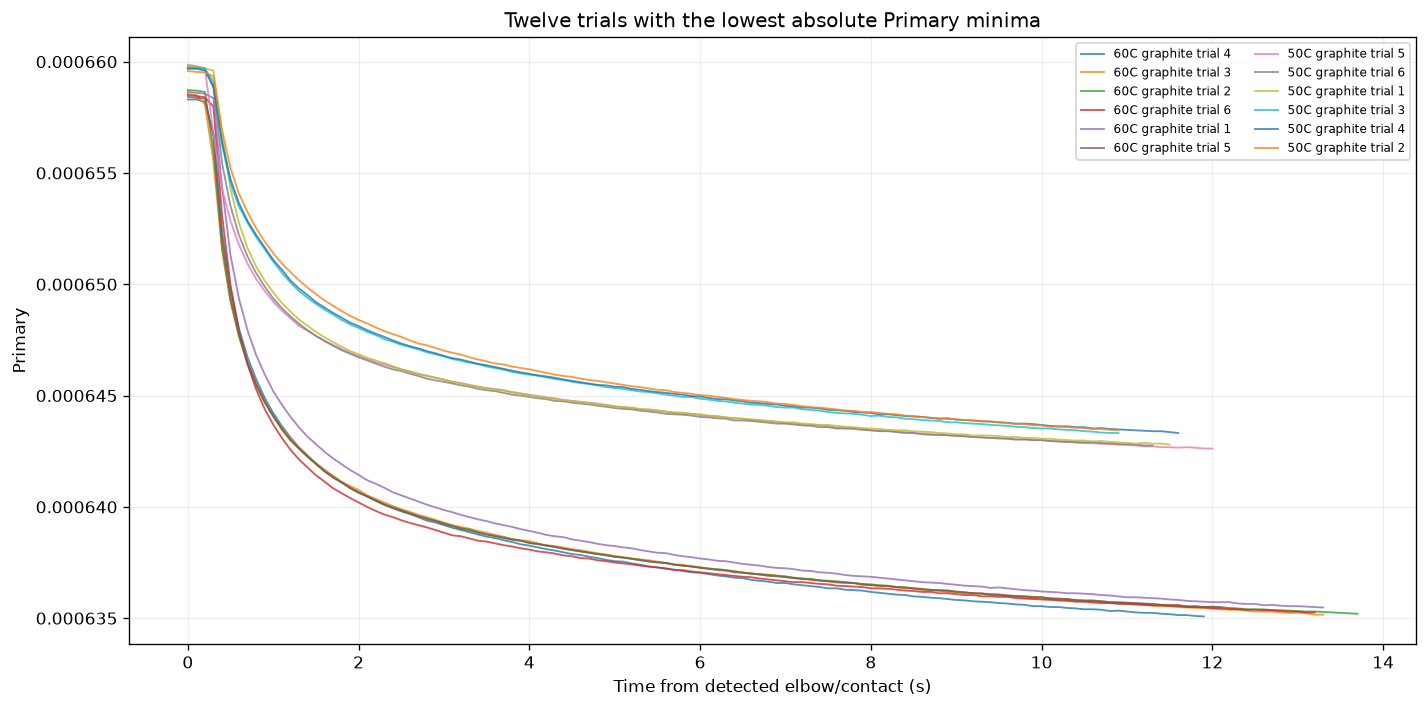

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/lowest_primary_raw_traces.png


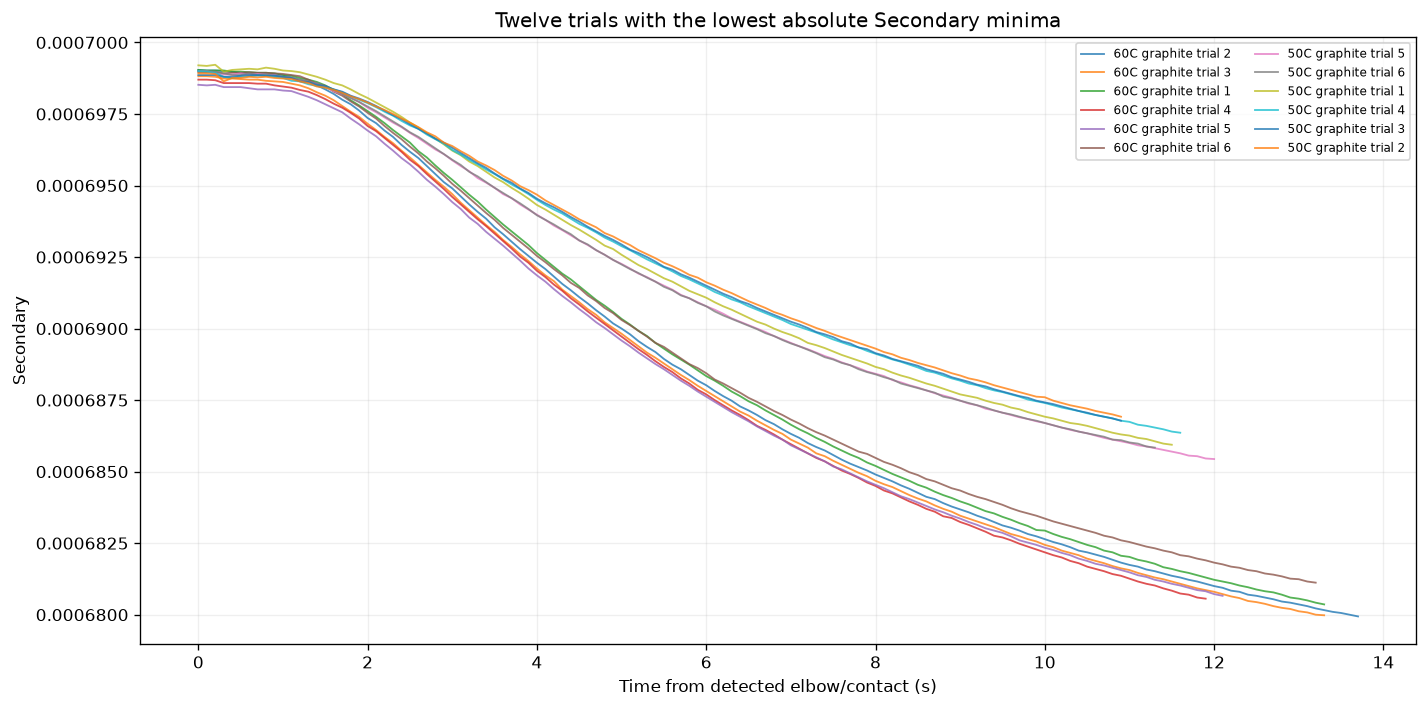

Saved: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/temporary_saturation_check/lowest_secondary_raw_traces.png


In [52]:
for sensor in SENSOR_COLUMNS:
    prefix = sensor.lower()
    selected = TRIAL_MINIMA.nsmallest(12, f"{prefix}_minimum")
    fig, axis = plt.subplots(figsize=(12, 6))
    for row in selected.itertuples():
        trial = DATA[DATA["trial_id"] == row.trial_id].sort_values("Time")
        axis.plot(
            trial["time_from_elbow"], trial[sensor], linewidth=1.1, alpha=0.8,
            label=f"{row.Temperature} {row.Sample} trial {row.Trial}",
        )
    axis.set_title(f"Twelve trials with the lowest absolute {sensor} minima")
    axis.set_xlabel("Time from detected elbow/contact (s)")
    axis.set_ylabel(sensor)
    axis.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    output = OUTPUT_DIR / f"lowest_{prefix}_raw_traces.png"
    fig.savefig(output, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", output)


# 12. Interpretation guide

Evidence consistent with saturation becomes stronger when several of these occur together:

1. different high-effusivity materials reach approximately the same **absolute** minimum;
2. their 1st and 5th percentiles also cluster close to that minimum;
3. the near-minimum fraction and longest run are high;
4. raw traces visibly flatten at the same level;
5. increasing temperature changes the time required to reach the floor but not the floor itself.

Similar curve shapes without a shared absolute floor do **not** by themselves demonstrate sensor saturation. They can arise from similar heat-transfer behavior, smoothing, normalization, or limited signal sensitivity.

If the floor exists only in the processed files, compare against the raw acquisition files to determine whether clipping occurred in the sensor/electronics or during preprocessing.

In [53]:
print("Saved diagnostic files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print(" -", path.name)


Saved diagnostic files:
 - all_metals_graphite_all_temperatures_mean_sd.png
 - all_trial_sensor_minima.csv
 - lowest_primary_raw_traces.png
 - lowest_secondary_raw_traces.png
 - material_temperature_sensor_minimum_summary.csv
 - near_minimum_plateau_heatmaps.png
 - same_material_all_trials_temperatures_aluminum.png
 - same_material_all_trials_temperatures_baseline_centered_aluminum.png
 - same_material_all_trials_temperatures_baseline_centered_bismuth.png
 - same_material_all_trials_temperatures_baseline_centered_copper.png
 - same_material_all_trials_temperatures_baseline_centered_graphite.png
 - same_material_all_trials_temperatures_baseline_centered_iron.png
 - same_material_all_trials_temperatures_baseline_centered_nickel.png
 - same_material_all_trials_temperatures_baseline_centered_titanium.png
 - same_material_all_trials_temperatures_bismuth.png
 - same_material_all_trials_temperatures_copper.png
 - same_material_all_trials_temperatures_elbow_aligned_aluminum.png
 - same_materia